In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ML_Assignment/heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (918, 12)

Columns:
 ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

Data types:
 Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Missing values:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Duplicate rows: 0


In [4]:
df.describe(include='all')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


In [5]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (918, 12)


In [6]:
print(df['HeartDisease'].value_counts())
print(df['HeartDisease'].value_counts(normalize=True) * 100)

HeartDisease
1    508
0    410
Name: count, dtype: int64
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


In [7]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [8]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numeric columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (734, 11)
X_test shape: (184, 11)


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

In [11]:
log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'RestingBP',
                                                   'Cholesterol', 'FastingBS',
                                                   'MaxHR', 'Oldpeak']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Sex', 'ChestPainType',
                                                   'RestingECG',
                                                   'ExerciseAngina',
                                                   'ST_Slope'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [12]:
y_pred = log_reg_pipeline.predict(X_test)
y_pred_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

In [13]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.8858695652173914
Precision: 0.8715596330275229
Recall: 0.9313725490196079
F1-score: 0.9004739336492891
ROC-AUC: 0.9307747489239598


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



In [15]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[68 14]
 [ 7 95]]


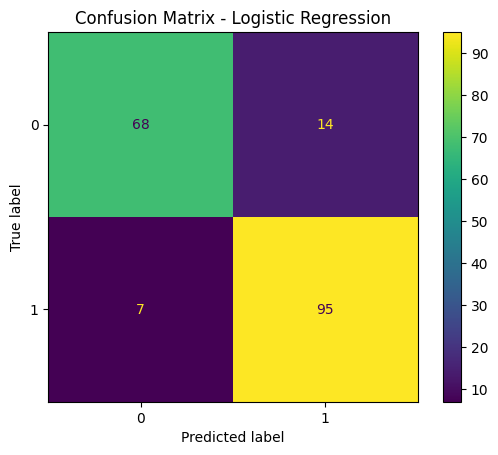

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [17]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    log_reg_pipeline, X, y,
    cv=5,
    scoring='accuracy'
)

print("Cross-validation accuracy scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std CV accuracy:", cv_scores.std())

Cross-validation accuracy scores: [0.85326087 0.8423913  0.8423913  0.86885246 0.76502732]
Mean CV accuracy: 0.8343846519363268
Std CV accuracy: 0.03600831415760337


In [18]:
cv_f1 = cross_val_score(
    log_reg_pipeline, X, y,
    cv=5,
    scoring='f1'
)

print("Mean CV F1-score:", cv_f1.mean())

Mean CV F1-score: 0.8481499303488832


In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'lbfgs'],
    'classifier__penalty': ['l2']
}

grid_search = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Best parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV score: 0.8555213866368465


In [20]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)
y_pred_best_proba = best_model.predict_proba(X_test)[:, 1]

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))
print("Tuned Precision:", precision_score(y_test, y_pred_best))
print("Tuned Recall:", recall_score(y_test, y_pred_best))
print("Tuned F1-score:", f1_score(y_test, y_pred_best))
print("Tuned ROC-AUC:", roc_auc_score(y_test, y_pred_best_proba))

Tuned Accuracy: 0.8804347826086957
Tuned Precision: 0.8773584905660378
Tuned Recall: 0.9117647058823529
Tuned F1-score: 0.8942307692307693
Tuned ROC-AUC: 0.932209469153515


In [21]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.88      0.84      0.86        82
           1       0.88      0.91      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



In [22]:
import numpy as np

# Get trained preprocessor and classifier
trained_preprocessor = best_model.named_steps['preprocessor']
trained_classifier = best_model.named_steps['classifier']

# Get feature names after preprocessing
encoded_cat_features = trained_preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = numeric_cols + list(encoded_cat_features)

# Coefficients
coefficients = trained_classifier.coef_[0]

coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
})

coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='AbsCoefficient', ascending=False)

coef_df.head(15)

,Feature,Coefficient,AbsCoefficient
14,ST_Slope_Up,-1.003961,1.003961
8,ChestPainType_NAP,-0.893941,0.893941
13,ST_Slope_Flat,0.855322,0.855322
7,ChestPainType_ATA,-0.772444,0.772444
12,ExerciseAngina_Y,0.762557,0.762557
6,Sex_M,0.658745,0.658745
2,Cholesterol,-0.397956,0.397956
5,Oldpeak,0.360611,0.360611
9,ChestPainType_TA,-0.359935,0.359935
3,FastingBS,0.358150,0.358150


In [23]:
print("Final Model Summary")
print("-------------------")
print("Best Parameters:", grid_search.best_params_)
print("Test Accuracy:", round(accuracy_score(y_test, y_pred_best), 4))
print("Test Precision:", round(precision_score(y_test, y_pred_best), 4))
print("Test Recall:", round(recall_score(y_test, y_pred_best), 4))
print("Test F1-score:", round(f1_score(y_test, y_pred_best), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_pred_best_proba), 4))

Final Model Summary
-------------------
Best Parameters: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Test Accuracy: 0.8804
Test Precision: 0.8774
Test Recall: 0.9118
Test F1-score: 0.8942
Test ROC-AUC: 0.9322


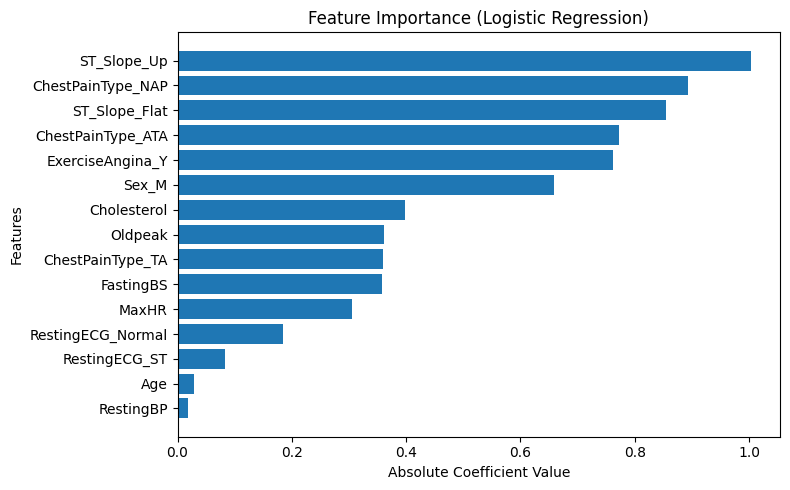

In [28]:
import matplotlib.pyplot as plt

coef_importance_df = coef_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(coef_importance_df['Feature'], coef_importance_df['Importance'])
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Features")
plt.title("Feature Importance (Logistic Regression)")
plt.tight_layout()
plt.show()

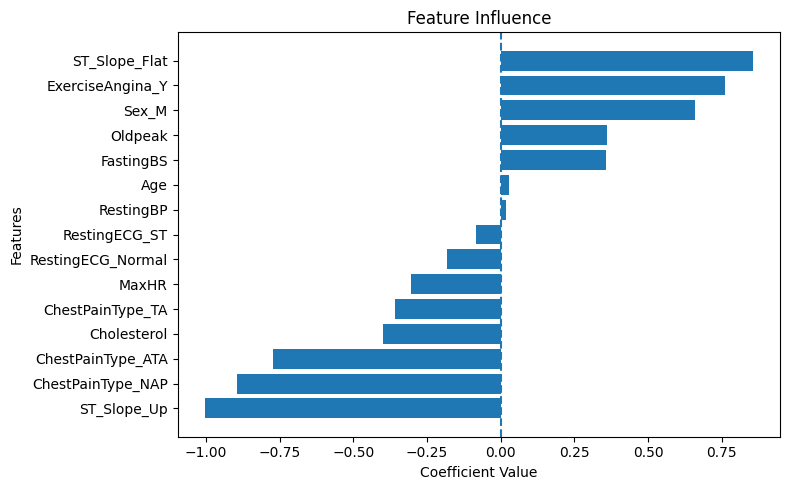

In [29]:
coef_signed_df = coef_df.sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(coef_signed_df['Feature'], coef_signed_df['Coefficient'])
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.title("Feature Influence")
plt.axvline(x=0, linestyle='--')
plt.tight_layout()
plt.show()

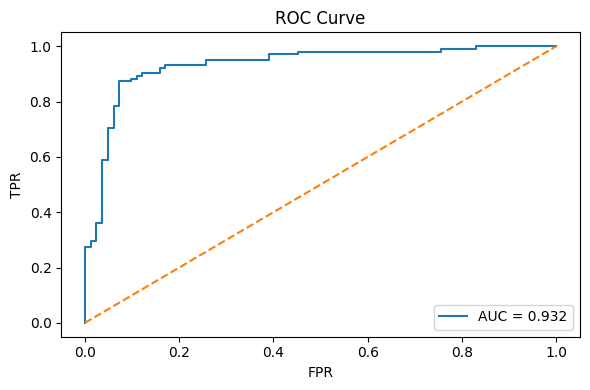

In [30]:
from sklearn.metrics import roc_curve, auc

y_pred_proba = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()